In [5]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\gorbe\anaconda3\envs\social-media-analytics\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
dataset = load_dataset(
    "QCRI/CrisisBench-english",
    "informativeness"
)

In [32]:
dataset

DatasetDict({
    test: Dataset({
        features: ['id', 'event', 'source', 'text', 'lang', 'lang_conf', 'class_label'],
        num_rows: 31095
    })
    dev: Dataset({
        features: ['id', 'event', 'source', 'text', 'lang', 'lang_conf', 'class_label'],
        num_rows: 16008
    })
    train: Dataset({
        features: ['id', 'event', 'source', 'text', 'lang', 'lang_conf', 'class_label'],
        num_rows: 109796
    })
})

In [33]:
dataset["train"][0]

{'id': '530',
 'event': 'disaster_events',
 'source': 'drd-figureeight-multimedia',
 'text': 'Organization that are working in Haiti, I do not have any ways of taking care of my family here',
 'lang': 'en',
 'lang_conf': '1',
 'class_label': 'informative'}

In [34]:
dataset["train"][0:5]

{'id': ['530',
  '913070034204884992',
  '540027128478044160',
  '17711',
  '778251007'],
 'event': ['disaster_events',
  'hurricane_maria',
  '2014_philippines_typhoon',
  'disaster_events',
  'disaster_events'],
 'source': ['drd-figureeight-multimedia',
  'crisismmd',
  'crisisnlp-cf',
  'drd-figureeight-multimedia',
  'dsm-cf'],
 'text': ['Organization that are working in Haiti, I do not have any ways of taking care of my family here',
  'Maria now a hurricane again!! Strong storm surge is an issue in #kitryhawk https://t.co/DSE2C5faKp https://t.co/vR63N0YZRY',
  "RT @ANCALERTS: Fallen tree branches scattered in Sorsogon City's streets. #RubyPH (Photo via @dennis_datu) http://t.co/ucab5G07ou",
  'The Government did not request international assistance.',
  'Remove http://t.co/77b2rNRTt7 Browser Hijacker - How t... http://t.co/Wff7X3B6KT'],
 'lang': ['en', 'en', 'en', 'en', 'en'],
 'lang_conf': ['1', 'NA', '0.9505285620689392', '1', '1'],
 'class_label': ['informative',
  'informativ

In [35]:
df = dataset["train"].to_pandas()

In [36]:
df.head()

,id,event,source,text,lang,lang_conf,class_label
0,530,disaster_events,drd-figureeight-multimedia,"Organization that are working in Haiti, I do n...",en,1,informative
1,913070034204884992,hurricane_maria,crisismmd,Maria now a hurricane again!! Strong storm sur...,en,NA,informative
2,540027128478044160,2014_philippines_typhoon,crisisnlp-cf,RT @ANCALERTS: Fallen tree branches scattered ...,en,0.9505285620689392,informative
3,17711,disaster_events,drd-figureeight-multimedia,The Government did not request international a...,en,1,informative
4,778251007,disaster_events,dsm-cf,Remove http://t.co/77b2rNRTt7 Browser Hijacker...,en,1,not_informative


In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 109796 entries, 0 to 109795
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   id           109796 non-null  str  
 1   event        109796 non-null  str  
 2   source       109796 non-null  str  
 3   text         109796 non-null  str  
 4   lang         109796 non-null  str  
 5   lang_conf    109796 non-null  str  
 6   class_label  109796 non-null  str  
dtypes: str(7)
memory usage: 5.9 MB


In [38]:
df.isnull().sum()

id             0
event          0
source         0
text           0
lang           0
lang_conf      0
class_label    0
dtype: int64

In [39]:
df['class_label'].value_counts()

class_label
informative        65826
not_informative    43970
Name: count, dtype: int64

In [40]:
df['event'].nunique()

61

In [41]:
df['event'].value_counts().head(20)

event
disaster_events                     25399
2015_nepal_earthquake                7760
2012_sandy_hurricane-ontopic         6206
2013_oklahoma_tornado-ontopic        6179
2013_alberta_floods-ontopic          6072
2013_boston_bombings-ontopic         5916
2013_west_texas                      5657
2014_philippines_typhoon-hagupit     5164
2013_queensland_floods-ontopic       4628
hurricane_harvey                     2779
hurricane_irma                       2774
hurricane_maria                      2758
2014-2015_worldwide_landslides       2229
2014_chile_earthquake                1562
2015_vanuatu_cyclone                 1438
2011_joplin_tornado-a131709          1157
2014_worldwide_ebola                 1147
2013_pakistan_earthquake             1080
2014_pakistan_floods                 1071
california_wildfires                 1041
Name: count, dtype: int64

<Axes: xlabel='class_label'>

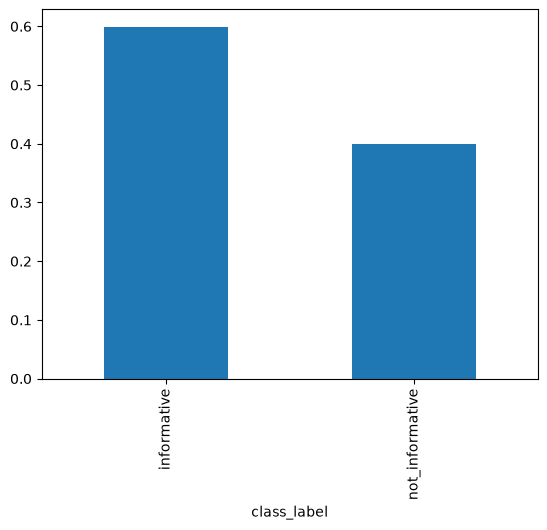

In [42]:
df['class_label'].value_counts(normalize=True).plot(kind='bar')

In [43]:
df.dtypes

id             str
event          str
source         str
text           str
lang           str
lang_conf      str
class_label    str
dtype: object

<Axes: title={'center': 'Class Distribution'}, xlabel='Class', ylabel='Number Of Posts'>

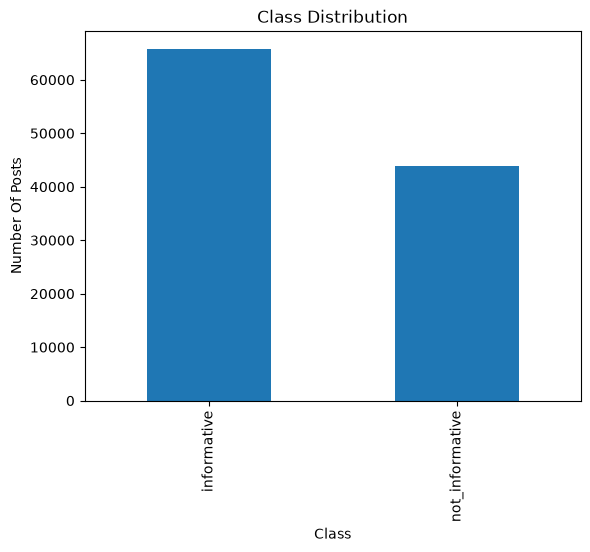

In [44]:
class_counts = df['class_label'].value_counts()

class_counts.plot(kind='bar', title='Class Distribution', xlabel='Class', ylabel='Number Of Posts')

In [45]:
event_counts = df['event'].value_counts()
event_counts.head(15)

event
disaster_events                     25399
2015_nepal_earthquake                7760
2012_sandy_hurricane-ontopic         6206
2013_oklahoma_tornado-ontopic        6179
2013_alberta_floods-ontopic          6072
2013_boston_bombings-ontopic         5916
2013_west_texas                      5657
2014_philippines_typhoon-hagupit     5164
2013_queensland_floods-ontopic       4628
hurricane_harvey                     2779
hurricane_irma                       2774
hurricane_maria                      2758
2014-2015_worldwide_landslides       2229
2014_chile_earthquake                1562
2015_vanuatu_cyclone                 1438
Name: count, dtype: int64

<Axes: title={'center': 'Top 15 Events'}, xlabel='Event', ylabel='Number Of Posts'>

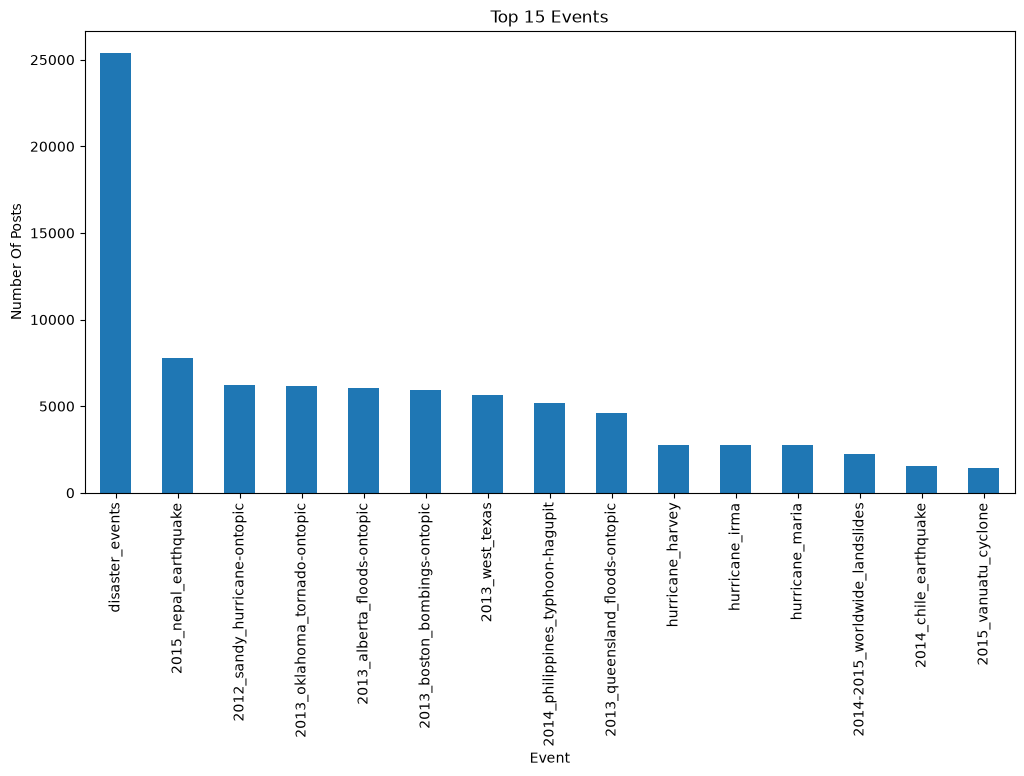

In [49]:
event_counts.head(15).plot(kind='bar', title='Top 15 Events', xlabel='Event', ylabel='Number Of Posts', figsize=(12, 6))

In [52]:
df['text_length'] = df['text'].str.len()

In [53]:
df['text_length'].describe()

count    109796.000000
mean        106.233296
std          49.714009
min           5.000000
25%          75.000000
50%         111.000000
75%         136.000000
max        4153.000000
Name: text_length, dtype: float64

<Axes: title={'center': 'Distribution of Social Media Post Length'}, ylabel='Frequency'>

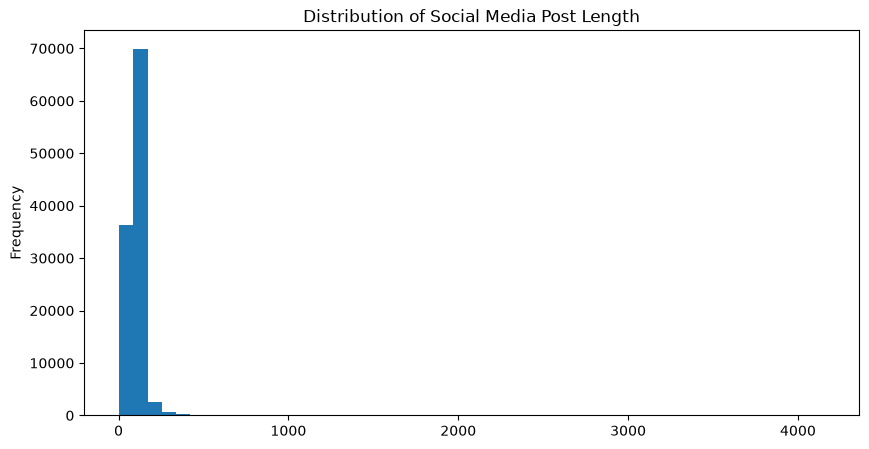

In [55]:
df['text_length'].plot(kind='hist', bins=50, title='Distribution of Social Media Post Length', figsize=(10, 5))

In [58]:
df[['text', 'class_label', 'event']].sample(5, random_state=42)

,text,class_label,event
86757,Slowly moving 'Ruby' to bring torrential rains...,not_informative,2014_philippines_typhoon-hagupit
89674,MT @dineshakula Med supplies required in Bir H...,informative,2015_nepal_earthquake
21192,The Chinese Embassy in Manila express condolen...,informative,2013_phillipines_typhoon-yolanda
36556,Rwanda remembers genocide victims 20 years on ...,not_informative,2014-2015_worldwide_landslides
6666,"FOX NEWS' NEW SHOW: ""OBJECTIFIED"" - With - Har...",not_informative,hurricane_harvey


In [59]:
from collections import Counter
words = ' '.join(df['text'].astype(str)).lower().split()
word_counts = Counter(words)
word_counts.most_common(20)

[('the', 52652),
 ('to', 37764),
 ('in', 34995),
 ('of', 28673),
 ('and', 25521),
 ('a', 22753),
 ('rt', 20492),
 ('for', 18054),
 ('i', 17287),
 ('is', 15161),
 ('on', 11192),
 ('you', 9919),
 ('are', 8541),
 ('at', 8524),
 ('my', 8299),
 ('this', 7855),
 ('with', 7818),
 ('from', 7550),
 ('that', 7498),
 ('-', 6953)]

In [61]:
df['source'].value_counts()

source
crisislext6                   34658
drd-figureeight-multimedia    14414
crisisnlp-volunteers          14357
crisisnlp-cf                  11806
crisismmd                     11179
crisislext26                  10159
dsm-cf                         6141
aidr_system                    4844
iscram13                       1688
swdm13                          550
Name: count, dtype: int64

In [66]:
from scipy import stats
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gorbe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gorbe\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gorbe\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [67]:
import re
import spacy
import emoji
import contractions

nlp = spacy.load("en_core_web_sm")

In [68]:
def clean_text(text):
    text = str(text)

    
    text = contractions.fix(text)

    text = emoji.demojize(text)

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [71]:
sample = df["text"].iloc[7]

print("ORIGINAL:")
print(sample)

print("\nCLEANED:")
print(clean_text(sample))

ORIGINAL:
"@Ndawsari @YemenPeaceNews @wondering2020 yup, see tweet chain."

CLEANED:
" yup, see tweet chain."


In [72]:
df['clean_text'] = df['text'].apply(clean_text)

In [74]:
negation_words = {"no", "not", "never", "none", "neither", "nor"}

def preprocess_text(text):
    doc = nlp(text)

    tokens = []

    for token in doc:
        if (
            not token.is_space
            and not token.is_punct
            and (
                not token.is_stop
                or token.text.lower() in negation_words
            )
        ):
            tokens.append(token.lemma_)

    return " ".join(tokens)

In [75]:
sample = df["clean_text"].iloc[0]

print("CLEANED:")
print(sample)

print("\nPREPROCESSED:")
print(preprocess_text(sample))

CLEANED:
organization that are working in haiti, i do not have any ways of taking care of my family here

PREPROCESSED:
organization work haiti not way take care family


In [76]:
texts = df["clean_text"].tolist()

preprocessed_texts = []

for doc in nlp.pipe(texts, batch_size=500):
    tokens = []

    for token in doc:
        if (
            not token.is_space
            and not token.is_punct
            and (
                not token.is_stop
                or token.text.lower() in negation_words
            )
        ):
            tokens.append(token.lemma_)

    preprocessed_texts.append(" ".join(tokens))

In [77]:
df["preprocessed_text"] = preprocessed_texts

In [79]:
df[["text", "clean_text", "preprocessed_text"]].sample(5, random_state=42)

,text,clean_text,preprocessed_text
86757,Slowly moving 'Ruby' to bring torrential rains...,slowly moving 'ruby' to bring torrential rains...,slowly move ruby bring torrential rain rubyph
89674,MT @dineshakula Med supplies required in Bir H...,mt med supplies required in bir hospital. out ...,mt med supply require bir hospital medical sup...
21192,The Chinese Embassy in Manila express condolen...,the chinese embassy in manila express condolen...,chinese embassy manila express condolence typh...
36556,Rwanda remembers genocide victims 20 years on ...,rwanda remembers genocide victims 20 years on -,rwanda remember genocide victim 20 year
6666,"FOX NEWS' NEW SHOW: ""OBJECTIFIED"" - With - Har...","fox news' new show: ""objectified"" - with - har...",fox news new objectified harvey levin depth in...


In [83]:
import pyarrow

In [85]:
df.to_pickle("C:/Users/gorbe/OneDrive/Desktop/COding/PROJECTS/social-media-analytics/data/processed/crisisbench_train_processed.pkl")

In [4]:
df.to_parquet(
    "../data/processed/crisisbench_train_processed.parquet",
    index=False
)

In [6]:
df = pd.read_parquet(
    "../data/processed/crisisbench_train_processed.parquet"
)

In [11]:
df['text'].duplicated().sum()
df["text"].duplicated(keep=False).sum()

np.int64(0)

In [12]:
(df['clean_text'].str.strip() == '').sum()

np.int64(0)

In [13]:
(df['clean_text'].str.len() < 10).sum()

np.int64(129)

In [14]:
df.to_parquet(
    '../data/processed/crisisbench_train_processed.parquet',
    index=False
)